In [ ]:
!pip install torch torchvision lpips kornia matplotlib tqdm

In [ ]:
# Cell 2: Imports and utility functions
import torch
import torch.profiler
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image
import lpips
import kornia
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

to_tensor = T.Compose([
    T.ToTensor(),  # Converts to [0,1]
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to [-1,1] for LPIPS
])

to_pil = T.Compose([
    T.Normalize(mean=[-1, -1, -1], std=[2, 2, 2]),
    T.ToPILImage()
])

In [ ]:
target_path = 'test-images/mac.png'     
cans_path = 'Logos/chiquita-logo.png'  

# === Configuration: Set your real-world sizes ===
canvas_width_in = 8.5     # canvas width in inches
canvas_height_in = 10.0    # canvas height in inches
can_width_in = 1.0        # can width in inches
can_height_in = 1.0       # can height in inches
dpi = 45                   # dots per inch (resolution)
downscale_factor = 1.0    # apply 25% scaling for optimization

# === Convert inches to pixels ===
canvas_width_px = int(canvas_width_in * dpi)
canvas_height_px = int(canvas_height_in * dpi)
can_width_px = int(can_width_in * dpi)
can_height_px = int(can_height_in * dpi)

print(f"Canvas: {canvas_width_px} x {canvas_height_px} px")
print(f"Each can: {can_width_px} x {can_height_px} px")

# === Load and resize target/can image ===
target_pil = Image.open(target_path).convert('RGB').resize((canvas_width_px, canvas_height_px))
can_pil = Image.open(can_path).convert('RGBA').resize((can_width_px, can_height_px))

# === Convert to full-resolution tensors ===
target_tensor_full = to_tensor(target_pil).unsqueeze(0).to(device)
can_rgb_full = to_tensor(can_pil.convert('RGB')).unsqueeze(0).to(device)
can_alpha_full = T.ToTensor()(can_pil.split()[-1]).unsqueeze(0).to(device)

# === Downscale all tensors for optimization ===
def downscale(tensor, factor):
    return F.interpolate(tensor, scale_factor=factor, mode='bilinear', align_corners=False)

target_tensor = downscale(target_tensor_full, downscale_factor)
can_rgb = downscale(can_rgb_full, downscale_factor)
can_alpha = F.interpolate(can_alpha_full, scale_factor=downscale_factor, mode='bilinear', align_corners=False)

# === Create blank canvas at downscaled resolution ===
canvas = torch.zeros_like(target_tensor).detach()


Canvas: 382 x 450 px
Each can: 45 x 45 px


In [92]:
# Cell 4: Multi-Can Placement and Optimization

import os
import glob
import torch
import torchvision.transforms as T
from PIL import Image
import lpips
import kornia.geometry.transform as KGT
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import numpy as np
import cv2

# === Load can images from the specified folder ===
def load_can_images(can_folder):
    can_paths = glob.glob(os.path.join(can_folder, '*.png')) + glob.glob(os.path.join(can_folder, '*.jpg')) + glob.glob(os.path.join(can_folder, '*.jpeg'))
    can_images = []
    for can_path in can_paths:
        try:
            can_pil = Image.open(can_path).convert('RGBA').resize((can_width_px, can_height_px))
            can_rgb_full = to_tensor(can_pil.convert('RGB')).unsqueeze(0).to(device)
            can_alpha_full = T.ToTensor()(can_pil.split()[-1]).unsqueeze(0).to(device)

            can_rgb = downscale(can_rgb_full, downscale_factor)
            can_alpha = F.interpolate(can_alpha_full, scale_factor=downscale_factor, mode='bilinear', align_corners=False)
            can_images.append((can_rgb, can_alpha))
        except Exception as e:
            print(f"Error loading image {can_path}: {e}")
    return can_images

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# === Define the number of cans to place ===
num_cans = 5  # Adjust as needed

# === Define the folder containing can images ===
can_folder = 'Logos/'  # Replace with the actual path to your can images folder
can_images = load_can_images(can_folder)
if not can_images:
    raise ValueError("No can images found in the specified folder.")

# === Load LPIPS metric ===
lpips_loss = lpips.LPIPS(net='vgg').to(device)

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: C:\Users\Eoin\AppData\Roaming\Python\Python312\site-packages\lpips\weights\v0.1\vgg.pth


In [93]:
# === Define the transformation functions (same as before) ===
import itertools
from matplotlib import animation


def create_transformation_matrix(x_offset, y_offset, rotation_angle, canvas_width, canvas_height):
    """Creates a transformation matrix for translation and rotation."""
    # Normalize offsets to range [-1, 1]
    x_offset_norm = (x_offset / canvas_width) * 2 - 1
    y_offset_norm = (y_offset / canvas_height) * 2 - 1

    # Create rotation matrix
    rotation_matrix = torch.eye(3)
    rotation_angle_rad = torch.deg2rad(torch.tensor(rotation_angle))
    rotation_matrix[0, 0] = torch.cos(rotation_angle_rad)
    rotation_matrix[0, 1] = -torch.sin(rotation_angle_rad)
    rotation_matrix[1, 0] = torch.sin(rotation_angle_rad)
    rotation_matrix[1, 1] = torch.cos(rotation_angle_rad)

    # Create translation matrix
    translation_matrix = torch.eye(3)
    translation_matrix[0, 2] = x_offset_norm
    translation_matrix[1, 2] = y_offset_norm

    # Combine rotation and translation (rotation first, then translation)
    transformation_matrix = translation_matrix @ rotation_matrix

    return transformation_matrix[0:2].unsqueeze(0).to(device)  # Return 2x3 matrix


def place_can(canvas, can_rgb, can_alpha, x_offset, y_offset, rotation_angle):
    """
    Places a can onto a canvas using OpenCV for affine warp and alpha blending,
    while assuming PyTorch tensor inputs.

    Args:
        canvas: torch.Tensor, shape (B, 3, H, W), float32, range [0,1]
        can_rgb: torch.Tensor, shape (B, 3, h, w)
        can_alpha: torch.Tensor, shape (B, 1, h, w), range [0,1]
        x_offset, y_offset: float — center coordinates to place can
        rotation_angle: float — degrees to rotate (clockwise is negative)

    Returns:
        Updated canvas (same shape), torch.Tensor
    """
    assert canvas.shape[0] == 1, "Batch size > 1 not supported"
    assert can_rgb.shape[0] == 1

    # Extract shapes
    canvas_tensor = canvas[0]
    can_rgb_tensor = can_rgb[0]
    can_alpha_tensor = can_alpha[0]

    # Convert to numpy
    canvas_np = canvas_tensor.permute(1, 2, 0).cpu().numpy()  # (H, W, 3)
    can_rgb_np = can_rgb_tensor.permute(1, 2, 0).cpu().numpy()  # (h, w, 3)
    can_alpha_np = can_alpha_tensor.squeeze(0).cpu().numpy()  # (h, w)

    # Create RGBA image
    can_alpha_np = np.clip(can_alpha_np, 0.0, 1.0)
    can_rgba_np = np.concatenate([can_rgb_np, can_alpha_np[..., np.newaxis]], axis=-1)  # (h, w, 4)

    h, w = can_rgba_np.shape[:2]
    center = (w // 2, h // 2)

    # Get OpenCV rotation matrix
    rot_matrix = cv2.getRotationMatrix2D(center, float(rotation_angle), 1.0)

    # Warp RGBA image
    warped_rgba = cv2.warpAffine(can_rgba_np, rot_matrix, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(0,0,0,0))

    # Compute placement on canvas
    canvas_h, canvas_w = canvas_np.shape[:2]
    x0 = int(x_offset - w // 2)
    y0 = int(y_offset - h // 2)
    x1 = x0 + w
    y1 = y0 + h

    # Clip canvas bounds
    x0_clip, y0_clip = max(0, x0), max(0, y0)
    x1_clip, y1_clip = min(canvas_w, x1), min(canvas_h, y1)

    # Clip can region
    can_x0 = x0_clip - x0
    can_y0 = y0_clip - y0
    can_x1 = can_x0 + (x1_clip - x0_clip)
    can_y1 = can_y0 + (y1_clip - y0_clip)

    # Extract regions
    can_crop = warped_rgba[can_y0:can_y1, can_x0:can_x1]
    can_rgb_crop = can_crop[:, :, :3]
    can_alpha_crop = can_crop[:, :, 3:4]

    canvas_crop = canvas_np[y0_clip:y1_clip, x0_clip:x1_clip].astype(np.float32)

    # Blend
    alpha = can_alpha_crop
    blended = (1 - alpha) * canvas_crop + alpha * can_rgb_crop

    # Place back into canvas
    canvas_np[y0_clip:y1_clip, x0_clip:x1_clip] = blended

    # Convert back to torch
    canvas_out = torch.from_numpy(canvas_np).permute(2, 0, 1).unsqueeze(0).to(canvas.device).type(canvas.dtype)

    return canvas_out

# === Multi-Can Optimization ===


import os
import matplotlib.pyplot as plt

def optimize_multi_can_placement(target_tensor, canvas, can_images, num_cans,
                                x_range, y_range, rotation_range,
                                num_iterations=64,  # Iterations per level
                                num_levels=3,  # Number of coarse-to-fine levels
                                grid_search_levels=1,  # Number of levels to use grid search
                                grid_steps=5,  # Number of grid steps per dimension
                                debug=False):  # Debug flag
    """
    Optimizes multi-can placement using coarse-to-fine search with grid search at coarser levels
    and random search at finer levels.

    Args:
        # ... (previous arguments remain the same)
        debug: If True, save debug images.
    """
    canvas_height, canvas_width = canvas.shape[2], canvas.shape[3]
    can_placements = []
    current_canvas = canvas.clone()

    # Create a directory for debug images if debug is True
    if debug:
        debug_dir = 'debug_images'
        os.makedirs(debug_dir, exist_ok=True)

    frame_count = 0

    # Sample random can image
    
    
    for can_idx in range(num_cans):
        can_index = random.randint(0, len(can_images) - 1)
        can_rgb, can_alpha = can_images[can_index]
        best_lpips_score = float('inf')
        best_x, best_y, best_rotation = 0, 0, 0
        best_can_index = 0

        # Initialize search ranges for the current can
        current_x_range = x_range
        current_y_range = y_range
        current_rotation_range = rotation_range

        print(f"\nInitial ranges for Can {can_idx + 1}:")
        print(f"X range: {current_x_range}")
        print(f"Y range: {current_y_range}")
        print(f"Rotation range: {current_rotation_range}")

        for level in range(num_levels):
            print(f"\nCan {can_idx + 1}/{num_cans}, Level {level + 1}/{num_levels}")
            print(f"Current X range: {current_x_range}")
            print(f"Current Y range: {current_y_range}")
            print(f"Current Rotation range: {current_rotation_range}")

            if level < grid_search_levels:
                # Grid Search
                print(f"Using Grid Search (Level {level + 1})")
                x_steps = torch.linspace(current_x_range[0], current_x_range[1], grid_steps)
                y_steps = torch.linspace(current_y_range[0], current_y_range[1], grid_steps)
                rotation_steps = torch.linspace(current_rotation_range[0], current_rotation_range[1], grid_steps)

                total_combinations = len(x_steps) * len(y_steps) * len(rotation_steps)
                with tqdm(total=total_combinations, desc=f"Grid Search Can {can_idx + 1}/{num_cans}, Level {level + 1}/{num_levels}") as pbar:
                    for step, (x, y, rotation) in enumerate(itertools.product(x_steps, y_steps, rotation_steps)):
                        

                        # Create a copy of the canvas for each placement attempt
                        temp_canvas = current_canvas.clone()

                        # Place the can on the canvas
                        temp_canvas = place_can(temp_canvas, can_rgb, can_alpha, x, y, rotation)

                        # Calculate LPIPS score
                        lpips_score = lpips_loss(temp_canvas, target_tensor).item()

                        # Update best score and placement if needed
                        if lpips_score < best_lpips_score:
                            best_lpips_score = lpips_score
                            best_x, best_y, best_rotation = x, y, rotation
                            best_can_index = can_index

                        # Update the progress bar with the current best score
                        pbar.set_postfix({'LPIPS': best_lpips_score})
                        pbar.update(1)

                        if debug and step % 10 == 0:  # Save every 10th frame to reduce the number of images
                            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
                            ax1.imshow(temp_canvas[0].cpu().permute(1, 2, 0).clamp(0, 1))
                            ax1.set_title(f"Current Placement")
                            ax1.axis('off')
                            ax2.imshow(can_rgb[0].cpu().permute(1, 2, 0).clamp(0, 1))
                            ax2.set_title(f"Current Can Image")
                            ax2.axis('off')
                            plt.suptitle(f"Can {can_idx + 1}, Level {level + 1} (Grid Search), Step {step + 1}/{total_combinations}")
                            plt.savefig(os.path.join(debug_dir, f'frame_{frame_count:04d}.png'))
                            plt.close(fig)
                            frame_count += 1

            else:
                # Random Search
                print(f"Using Random Search (Level {level + 1})")
                with tqdm(total=num_iterations, desc=f"Random Search Can {can_idx + 1}/{num_cans}, Level {level + 1}/{num_levels}") as pbar:
                    for i in range(num_iterations):

                        # Sample random placement parameters within the current ranges
                        x = torch.rand(1).item() * (current_x_range[1] - current_x_range[0]) + current_x_range[0]
                        y = torch.rand(1).item() * (current_y_range[1] - current_y_range[0]) + current_y_range[0]
                        rotation = torch.rand(1).item() * (current_rotation_range[1] - current_rotation_range[0]) + current_rotation_range[0]

                        # Create a copy of the canvas for each placement attempt
                        temp_canvas = current_canvas.clone()

                        # Place the can on the canvas
                        temp_canvas = place_can(temp_canvas, can_rgb, can_alpha, x, y, rotation)

                        # Calculate LPIPS score
                        lpips_score = lpips_loss(temp_canvas, target_tensor).item()

                        # Update best score and placement if needed
                        if lpips_score < best_lpips_score:
                            best_lpips_score = lpips_score
                            best_x, best_y, best_rotation = x, y, rotation
                            best_can_index = can_index

                        # Update the progress bar with the current best score
                        pbar.set_postfix({'LPIPS': best_lpips_score})
                        pbar.update(1)

                        if debug and i % 5 == 0:  # Save every 5th frame to reduce the number of images
                            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
                            ax1.imshow(temp_canvas[0].cpu().permute(1, 2, 0).clamp(0, 1))
                            ax1.set_title(f"Current Placement")
                            ax1.axis('off')
                            ax2.imshow(can_rgb[0].cpu().permute(1, 2, 0).clamp(0, 1))
                            ax2.set_title(f"Current Can Image")
                            ax2.axis('off')
                            plt.suptitle(f"Can {can_idx + 1}, Level {level + 1} (Random Search), Iteration {i + 1}/{num_iterations}")
                            plt.savefig(os.path.join(debug_dir, f'frame_{frame_count:04d}.png'))
                            plt.close(fig)
                            frame_count += 1

            print(f"Can {can_idx + 1}, Level {level + 1}: Best LPIPS score: {best_lpips_score}")
            print(f"Can {can_idx + 1}, Level {level + 1}: Best x: {best_x}, Best y: {best_y}, Best rotation: {best_rotation}")

            # Refine the search ranges for the next level
            x_range_width = float(current_x_range[1] - current_x_range[0])
            y_range_width = float(current_y_range[1] - current_y_range[0])
            rotation_range_width = float(current_rotation_range[1] - current_rotation_range[0])

            # Reduce the search range by half around the best values
            current_x_range = (max(x_range[0], float(best_x) - x_range_width / 4), min(x_range[1], float(best_x) + x_range_width / 4))
            current_y_range = (max(y_range[0], float(best_y) - y_range_width / 4), min(y_range[1], float(best_y) + y_range_width / 4))
            current_rotation_range = (max(rotation_range[0], float(best_rotation) - rotation_range_width / 4), min(rotation_range[1], float(best_rotation) + rotation_range_width / 4))

            print(f"\nUpdated ranges for next level:")
            print(f"New X range: {current_x_range}")
            print(f"New Y range: {current_y_range}")
            print(f"New Rotation range: {current_rotation_range}")
            
        # After all levels, place the best can on the current canvas
        best_can_rgb, best_can_alpha = can_images[best_can_index]
        print("bout to place the best can on the current canvas best x, best y, best rotation: ", best_x, best_y, best_rotation)
        current_canvas = place_can(current_canvas, best_can_rgb, best_can_alpha, best_x, best_y, best_rotation)

        # Store the can placement
        can_placements.append((best_x, best_y, best_rotation, best_can_index))

    return current_canvas, can_placements

In [99]:


num_cans = 84  # Adjust as needed

# === Define the folder containing can images ===
can_folder = 'logos_picked/'  # Replace with the actual path to your can images folder
can_images = load_can_images(can_folder)
if not can_images:
    raise ValueError("No can images found in the specified folder.")

# === Define search ranges ===
x_range = (0, canvas_width_px * downscale_factor)  # X offset range
y_range = (0, canvas_height_px * downscale_factor) # Y offset range
rotation_range = (-180, 180)                       # Rotation range in degrees

# === Run the multi-can optimization ===
final_canvas, can_placements = optimize_multi_can_placement(
    target_tensor, canvas, can_images, num_cans,
    x_range, y_range, rotation_range,
    num_iterations=32, num_levels=4,  # Adjust as needed
    grid_search_levels=2, grid_steps=5, debug=True
)





Initial ranges for Can 1:
X range: (0, 382.0)
Y range: (0, 450.0)
Rotation range: (-180, 180)

Can 1/84, Level 1/4
Current X range: (0, 382.0)
Current Y range: (0, 450.0)
Current Rotation range: (-180, 180)
Using Grid Search (Level 1)


Grid Search Can 1/84, Level 1/4: 100%|██████████| 125/125 [03:20<00:00,  1.60s/it, LPIPS=0.931]


Can 1, Level 1: Best LPIPS score: 0.9308750629425049
Can 1, Level 1: Best x: 191.0, Best y: 450.0, Best rotation: -180.0

Updated ranges for next level:
New X range: (95.5, 286.5)
New Y range: (337.5, 450.0)
New Rotation range: (-180, -90.0)

Can 1/84, Level 2/4
Current X range: (95.5, 286.5)
Current Y range: (337.5, 450.0)
Current Rotation range: (-180, -90.0)
Using Grid Search (Level 2)


Grid Search Can 1/84, Level 2/4: 100%|██████████| 125/125 [03:02<00:00,  1.46s/it, LPIPS=0.931]


Can 1, Level 2: Best LPIPS score: 0.9308750629425049
Can 1, Level 2: Best x: 191.0, Best y: 450.0, Best rotation: -180.0

Updated ranges for next level:
New X range: (143.25, 238.75)
New Y range: (421.875, 450.0)
New Rotation range: (-180, -157.5)

Can 1/84, Level 3/4
Current X range: (143.25, 238.75)
Current Y range: (421.875, 450.0)
Current Rotation range: (-180, -157.5)
Using Random Search (Level 3)


...

Can 47, Level 2: Best LPIPS score: 0.8455923199653625
Can 47, Level 2: Best x: 358.125, Best y: 168.75, Best rotation: 45.0

Updated ranges for next level:
New X range: (334.25, 382.0)
New Y range: (112.5, 225.0)
New Rotation range: (0.0, 90.0)

Can 47/84, Level 3/4
Current X range: (334.25, 382.0)
Current Y range: (112.5, 225.0)
Current Rotation range: (0.0, 90.0)
Using Random Search (Level 3)


Random Search Can 47/84, Level 3/4: 100%|██████████| 32/32 [00:45<00:00,  1.41s/it, LPIPS=0.845]


Can 47, Level 3: Best LPIPS score: 0.8452094197273254
Can 47, Level 3: Best x: 354.7511076182127, Best y: 150.88961943984032, Best rotation: 64.93366777896881

Updated ranges for next level:
New X range: (342.8136076182127, 366.6886076182127)
New Y range: (122.76461943984032, 179.01461943984032)
New Rotation range: (42.43366777896881, 87.43366777896881)

Can 47/84, Level 4/4
Current X range: (342.8136076182127, 366.6886076182127)
Current Y range: (122.76461943984032, 179.01461943984032)
Current Rotation range: (42.43366777896881, 87.43366777896881)
Using Random Search (Level 4)


Random Search Can 47/84, Level 4/4:   9%|▉         | 3/32 [00:08<01:29,  3.08s/it, LPIPS=0.845]

: 

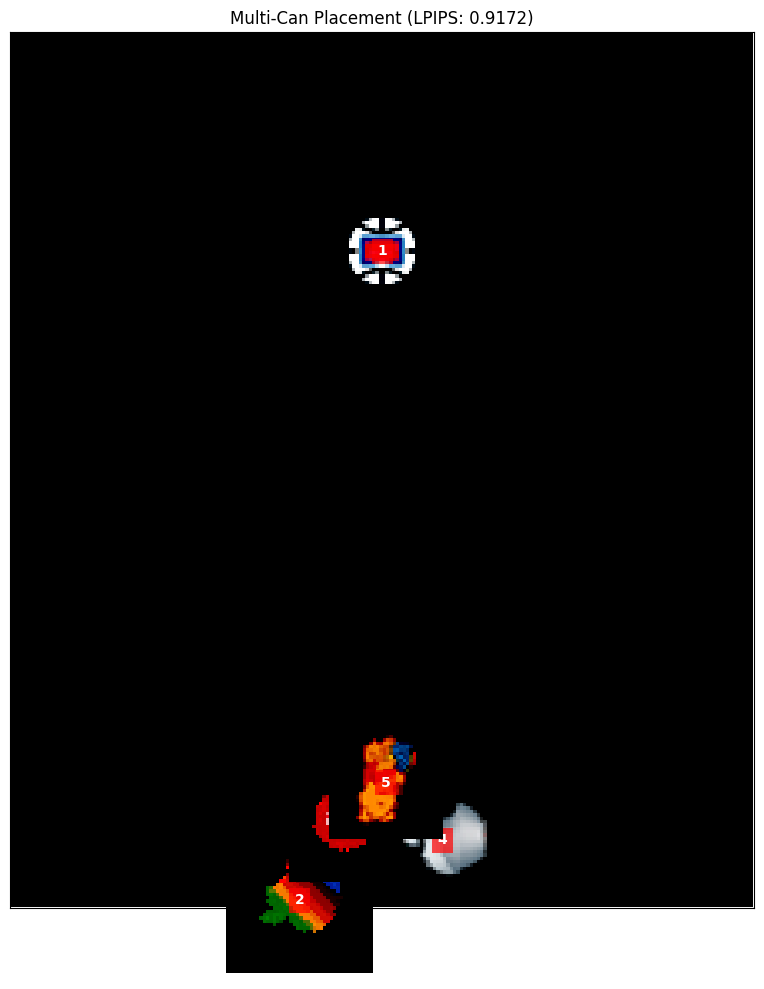


Can Placements:
Can 1: x=127.50, y=75.00, rotation=90.00, image_index=10
Can 2: x=99.25, y=297.28, rotation=-136.90, image_index=1
Can 3: x=118.47, y=268.07, rotation=-112.91, image_index=19
Can 4: x=148.21, y=276.83, rotation=-95.88, image_index=0
Can 5: x=128.78, y=257.01, rotation=-171.97, image_index=3


In [90]:

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torchvision.transforms.functional as TF
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# === Display the result ===
fig, ax = plt.subplots(figsize=(canvas_width_in, canvas_height_in))
ax.imshow(final_canvas[0].cpu().permute(1, 2, 0).clamp(0, 1))
ax.set_title(f"Multi-Can Placement (LPIPS: {lpips_loss(final_canvas, target_tensor).item():.4f})")

# === Manually plot the cans on the canvas ===
for i, (x, y, rotation, can_index) in enumerate(can_placements):
    can_rgb, can_alpha = can_images[can_index]
    can_height, can_width = can_rgb.shape[2], can_rgb.shape[3]

    # Calculate the can's position on the canvas
    can_x = x / downscale_factor
    can_y = y / downscale_factor

    # Convert can image to PIL Image
    can_pil = TF.to_pil_image(can_rgb[0].cpu().clamp(0, 1))

    # Rotate the can image (convert rotation to float)
    can_pil_rotated = TF.rotate(can_pil, -float(rotation), expand=True)

    # Calculate the new size after rotation
    new_width, new_height = can_pil_rotated.size

    # Create an OffsetImage with the rotated can
    im = OffsetImage(can_pil_rotated, zoom=1 / (dpi / 72))  # Adjust zoom factor based on DPI
    ab = AnnotationBbox(im, (can_x, can_y), xycoords='data', frameon=False)

    # Add the image to the plot
    ax.add_artist(ab)

    # Create a rectangle patch for the can (optional, for debugging)
    rect = patches.Rectangle((can_x - can_width/2, can_y - can_height/2), can_width, can_height, 
                             fill=False, edgecolor='r', linewidth=2)
    
    # Rotate the rectangle
    transform = patches.transforms.Affine2D().rotate_deg_around(can_x, can_y, float(rotation)) + ax.transData
    rect.set_transform(transform)

    # Add the rectangle to the plot (optional, for debugging)
    ax.add_patch(rect)

    # Add can number label
    ax.text(can_x, can_y, str(i+1), color='white', fontweight='bold', 
            ha='center', va='center', bbox=dict(facecolor='red', edgecolor='none', alpha=0.7))

# Set the correct aspect ratio and limits
ax.set_xlim(0, canvas_width_px)
ax.set_ylim(canvas_height_px, 0)  # Invert y-axis to match image coordinates
ax.set_aspect('equal', 'box')

# Remove axis ticks
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

# === Print can placements ===
print("\nCan Placements:")
for i, (x, y, rotation, can_index) in enumerate(can_placements):
    print(f"Can {i + 1}: x={x:.2f}, y={y:.2f}, rotation={float(rotation):.2f}, image_index={can_index}")